In [1]:
!pip install roboflow -q

from roboflow import Roboflow
import yaml
from collections import Counter
import os
from pathlib import Path

# Download the dataset
rf = Roboflow(api_key="J1mmAuxLk77g4eiOvCmr")
project = rf.workspace("a-0sh7s").project("underwater-plastic-detection-j6ram")
dataset = project.version(1).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [2]:
# The download returns a dataset object with .location
dataset_location = dataset.location
print(f"Dataset downloaded to: {dataset_location}")

# -------------------------------
# 1. Load data.yaml
# -------------------------------
yaml_path = os.path.join(dataset_location, "data.yaml")

with open(yaml_path, 'r') as file:
    data = yaml.safe_load(file)

# Extract class names
class_names = data['names']
print("\nClass Names:")
for idx, name in enumerate(class_names):
    print(f"  {idx}: {name}")

num_classes = len(class_names)
print(f"\nTotal Classes: {num_classes}")

# -------------------------------
# 2. Count total images
# -------------------------------
def count_images(split):
    img_dir = os.path.join(dataset_location, split, "images")
    if not os.path.exists(img_dir):
        return 0
    return len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])

total_images = (
    count_images("train") +
    count_images("valid") +
    count_images("test")
)

print(f"\nTotal Images: {total_images}")
print(f"  Train: {count_images('train')}")
print(f"  Valid: {count_images('valid')}")
print(f"  Test : {count_images('test')}")

# -------------------------------
# 3. Count labels per class
# -------------------------------
def count_labels_per_class(split):
    label_dir = os.path.join(dataset_location, split, "labels")
    if not os.path.exists(label_dir):
        return Counter()
    
    class_counter = Counter()
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    
    for label_file in label_files:
        with open(os.path.join(label_dir, label_file), 'r') as f:
            lines = f.readlines()
            for line in lines:
                if line.strip():  # skip empty lines
                    class_id = int(line.split()[0])
                    class_counter[class_id] += 1
    return class_counter

print("\nNumber of object instances per class (across all splits):")
total_counter = Counter()

for split in ["train", "valid", "test"]:
    counter = count_labels_per_class(split)
    total_counter += counter
    if counter:
        print(f"\n  {split.capitalize()} split:")
        for class_id in sorted(counter.keys()):
            print(f"    {class_names[class_id]:25} ({class_id}): {counter[class_id]}")

# Final summary
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"Total Images          : {total_images}")
print(f"Total Classes         : {num_classes}")
print(f"Total Object Instances: {sum(total_counter.values())}")
print("\nPer-class instance count:")
for class_id in sorted(total_counter.keys()):
    print(f"  {class_names[class_id]:25}: {total_counter[class_id]}")
print("="*50)

Dataset downloaded to: /kaggle/working/underwater-plastic-detection-1

Class Names:
  0: animal_crab
  1: animal_eel
  2: animal_etc
  3: animal_fish
  4: animal_shells
  5: animal_starfish
  6: plant
  7: rov
  8: trash_bag
  9: trash_bottle
  10: trash_branch
  11: trash_can
  12: trash_clothing
  13: trash_container
  14: trash_cup
  15: trash_net
  16: trash_pipe
  17: trash_rope
  18: trash_snack_wrapper
  19: trash_tarp
  20: trash_unknown_instance
  21: trash_wreckage

Total Classes: 22

Total Images: 6064
  Train: 4244
  Valid: 1213
  Test : 607

Number of object instances per class (across all splits):

  Train split:
    animal_crab               (0): 163
    animal_eel                (1): 194
    animal_etc                (2): 110
    animal_fish               (3): 425
    animal_shells             (4): 127
    animal_starfish           (5): 166
    plant                     (6): 267
    rov                       (7): 1914
    trash_bag                 (8): 503
    trash_bot

In [3]:
# FIX FOR NUMPY 2.0+ COMPATIBILITY ISSUE IN COLAB
#!pip install "numpy<2" --force-reinstall -q

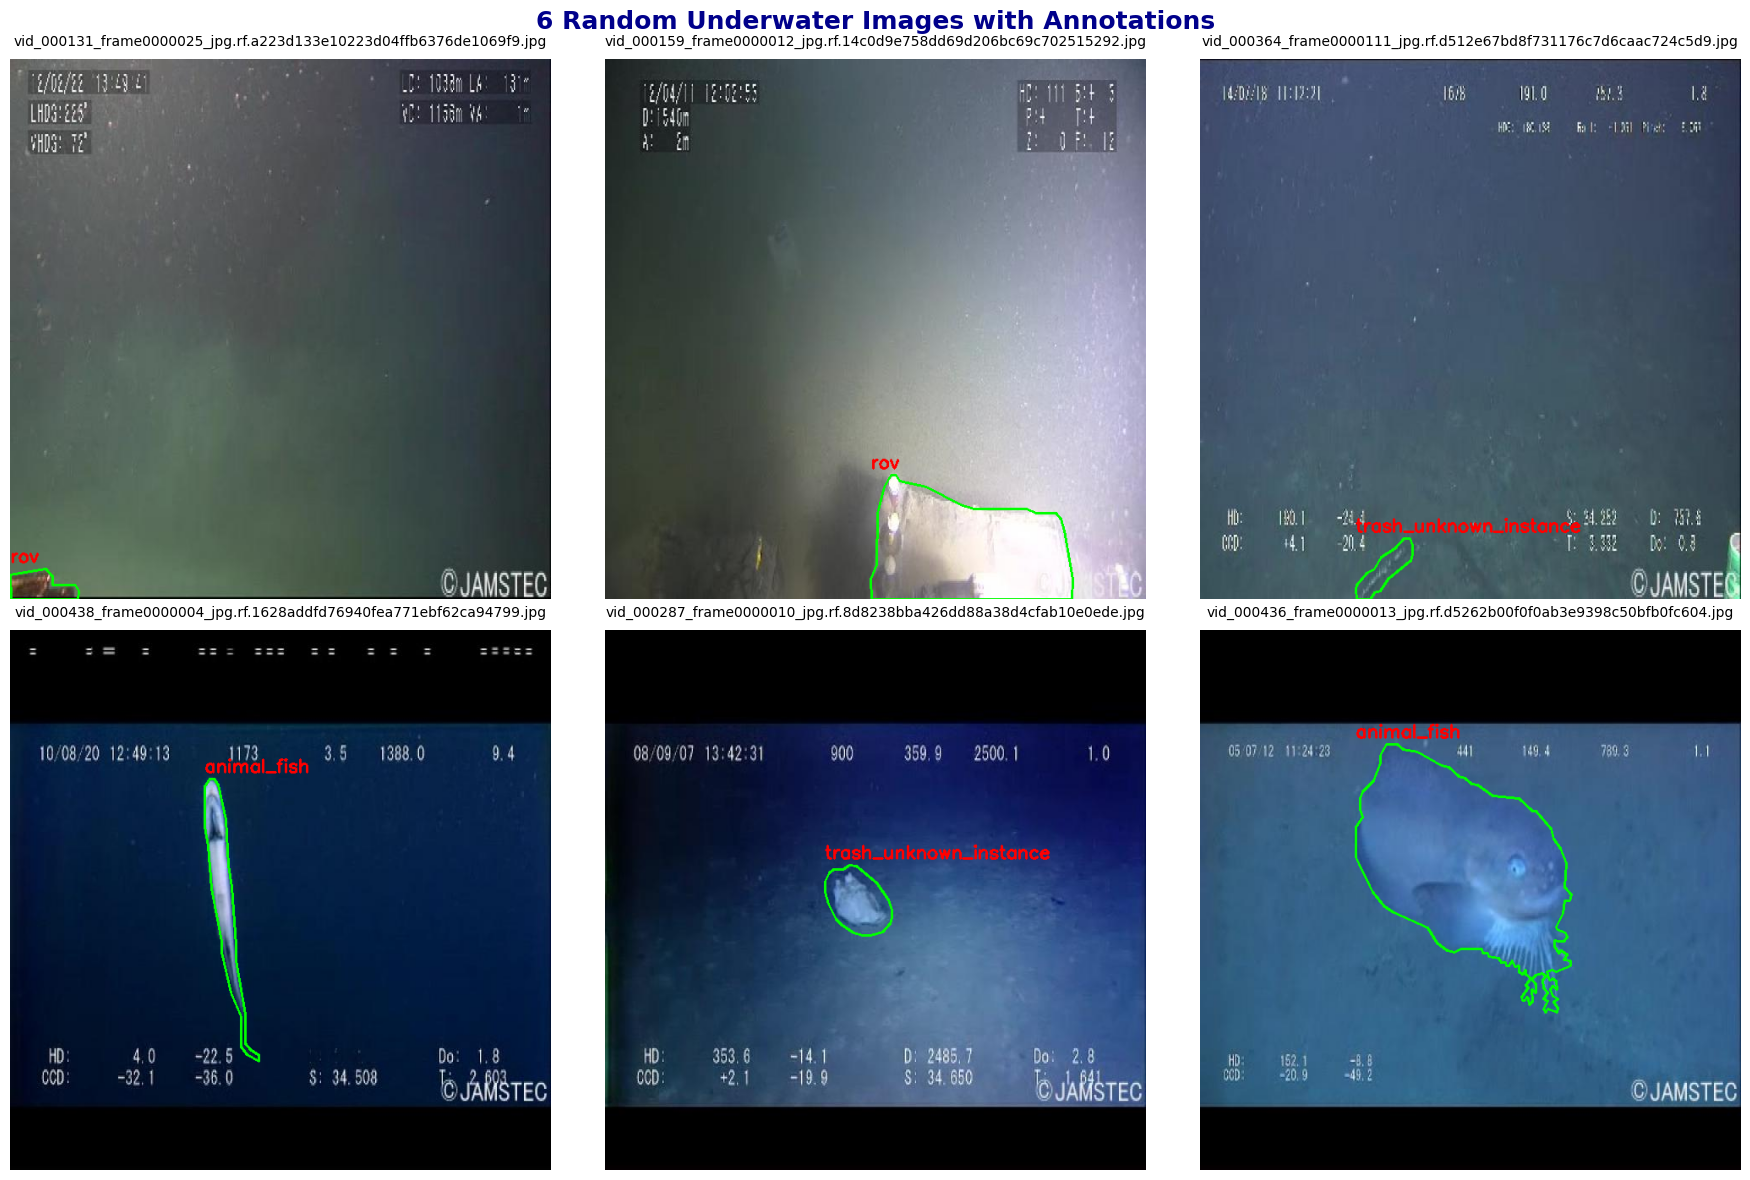

In [4]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def draw_yolo_boxes(image_path, label_path, class_names):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    annotated = img.copy()

    if not os.path.exists(label_path):
        return annotated                                    # no label file → still show image

    with open(label_path, 'r') as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if not lines:
        return annotated                                    # empty label file → still show image

    for line in lines:
        values = list(map(float, line.split()))
        class_id = int(values[0])
        class_name = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"

        # Detection format (5 values)
        if len(values) == 5:
            _, x_c, y_c, bw, bh = values
            x1 = int((x_c - bw/2) * w)
            y1 = int((y_c - bh/2) * h)
            x2 = int((x_c + bw/2) * w)
            y2 = int((y_c + bh/2) * h)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(annotated, class_name, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

        # Segmentation format (many values)
        elif len(values) > 5 and len(values) % 2 == 1:
            pts = np.array(values[1:]).reshape(-1, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
            pts = pts.astype(int)
            cv2.polylines(annotated, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
            x1, y1 = pts.min(axis=0)
            cv2.putText(annotated, class_name, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    return annotated

# ================================
# Pick 6 RANDOM images (different every run)
# ================================
all_image_paths = []
all_label_paths = []

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset_location, split, "images")
    lbl_dir = os.path.join(dataset_location, split, "labels")
    if not os.path.exists(img_dir):
        continue
    for img_file in os.listdir(img_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(img_dir, img_file))
            all_label_paths.append(os.path.join(lbl_dir, Path(img_file).stem + ".txt"))

# Shuffle and pick 6 (truly random every time!)
combined = list(zip(all_image_paths, all_label_paths))
random.shuffle(combined)                     # ← this makes it different every run
selected = combined[:6]

# Plot
plt.figure(figsize=(18, 12))
for i, (img_path, lbl_path) in enumerate(selected):
    img = draw_yolo_boxes(img_path, lbl_path, class_names)
    if img is None:
        continue
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(img_path).name, fontsize=10, pad=10)

plt.suptitle("6 Random Underwater Images with Annotations", 
             fontsize=18, fontweight="bold", color="darkblue")
plt.tight_layout()
plt.show()

In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 115.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
from ultralytics import YOLO
import os
from pathlib import Path

# ==================== CONFIGURATION ====================
# UPDATE THESE PATHS ACCORDING TO YOUR SETUP
dataset_location = "/kaggle/working/underwater-plastic-detection-1" 


# Path to your data.yaml file (you need to create this!)
data_yaml = os.path.join(dataset_location, "data.yaml")

# Choose model size: 
# Options: yolo11n.pt (nano), yolo11s.pt (small), yolo11m.pt (medium), yolo11l.pt (large), yolo11x.pt (extra large)
model_variant = "yolo11s.pt"   # Good balance of speed/accuracy for most custom datasets

# Training hyperparameters
epochs = 100
imgsz = 640
batch_size = 16
patience = 20  # Early stopping if no improvement
project_name = "underwater_yolo11"
run_name = "yolo11s_underwater_v1"

# =======================================================

def create_data_yaml_if_missing():
    """Creates a minimal data.yaml if it doesn't exist"""
    if os.path.exists(data_yaml):
        print(f"Found existing data.yaml: {data_yaml}")
        return

    print("data.yaml not found. Creating a basic one...")
    content = f"""
path: {os.path.abspath(dataset_location)}  # dataset root dir
train: train/images
val: valid/images
test: test/images  # optional

# Classes (UPDATE THIS LIST WITH YOUR ACTUAL CLASSES!)
names:
  0: fish
  1: starfish
  2: crab
  3: coral
  4: diver
  # Add more as needed...
"""
    with open(data_yaml, "w") as f:
        f.write(content.strip())
    print(f"Created {data_yaml}")
    print("WARNING: Please EDIT the 'names' section with your actual class names!")

# Create data.yaml if missing
create_data_yaml_if_missing()

# Load a fresh YOLO11 model
model = YOLO(model_variant)  # or YOLO("yolo11s.pt")

# Start training
results = model.train(
    data=data_yaml,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    patience=patience,
    project=project_name,
    name=run_name,
    exist_ok=True,
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    augment=True,           # Enable default augmentations (mosaic, flip, etc.)
    mosaic=1.0,             # Great for underwater (helps with small objects)
    mixup=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    cache="disk",           # Speeds up training if you have enough disk space
    workers=8,
    seed=42,
    plots=True,
    save=True,
    val=True,
    close_mosaic=10         # Disable mosaic in last 10 epochs for better convergence
)

# ==================== AFTER TRAINING ====================
# Best model will be saved as: runs/detect/underwater_yolo11/yolo11s_underwater_v1/weights/best.pt

print("\n" + "="*60)
print("TRAINING COMPLETED!")
print(f"Best model: {results.save_dir}/weights/best.pt")
print(f"Results saved in: {results.save_dir}")
print("="*60)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Found existing data.yaml: /kaggle/working/underwater-plastic-detection-1/data.yaml
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/underwater-plastic-detection-1/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchsc

In [8]:
from ultralytics import YOLO
import cv2
import os
from pathlib import Path

# ==================== PREDICTION SETTINGS ====================
# Path to your trained best model (update if you moved it)
model_path = "underwater_yolo11/yolo11s_underwater_v1/weights/best.pt"

# Input: either a single image, a folder of images, or a video
source = "/kaggle/working/underwater-plastic-detection-1/test/images/vid_000022_frame0000017_jpg.rf.d88dc4cad0782a18a8cd248ee32c1f84.jpg"          # ← Change this: path to image/folder/video or "0" for webcam

# Output settings
save_results = True              # Save annotated images/videos
output_dir = "prediction_results"
conf_threshold = 0.25    # Confidence threshold
imgsz = 640              # Same as training

# ============================================================

# Load your trained model
model = YOLO(model_path)

# Run inference
results = model.predict(
    source=source,
    save=save_results,
    save_txt=False,         # Set True if you want .txt labels
    save_conf=True,
    conf=conf_threshold,
    imgsz=imgsz,
    project=output_dir,
    name="pred",
    exist_ok=True,
    device=0 if cv2.cuda.getCudaEnabledDeviceCount() > 0 else "cpu",  # Use GPU if available
    show=False,             # Set True to display results live
    stream=False            # Set True for video/webcam streaming
)

print(f"\nPrediction finished! Results saved in: {output_dir}/pred")


image 1/1 /kaggle/working/underwater-plastic-detection-1/test/images/vid_000022_frame0000017_jpg.rf.d88dc4cad0782a18a8cd248ee32c1f84.jpg: 640x640 1 trash_unknown_instance, 284.8ms
Speed: 3.0ms preprocess, 284.8ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/prediction_results/pred

Prediction finished! Results saved in: prediction_results/pred


In [12]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=5b0499a9f099a5d0db1e774139b11a04dc326d71e088d8d02a1436e3d7a02e0a
  Stored in directory: /root/.cache/pip/wheels/bc/52/78/893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam


In [17]:
!pip install grad-cam -q
!pip install ttach  

In [23]:
# No extra installs needed!

from ultralytics import YOLO
from ultralytics.data.augment import LetterBox
import torch
import cv2
import numpy as np
import os
from pathlib import Path

# --------------------- CHANGE ONLY THIS LINE ---------------------
image_path = "/kaggle/working/underwater-plastic-detection-1/test/images/vid_000005_frame0000011_jpg.rf.124a7a927d1ec98a89401f3311475a32.jpg"
# -----------------------------------------------------------------

model_path = "/kaggle/working/underwater_yolo11/yolo11s_underwater_v1/weights/best.pt"
model = YOLO(model_path)

output_dir = "/kaggle/working/gradcam_single_image"
os.makedirs(output_dir, exist_ok=True)

class_names = [
    "animal_crab", "animal_eel", "animal_etc", "animal_fish", "animal_shells",
    "animal_starfish", "plant", "rov", "trash_bag", "trash_bottle",
    "trash_branch", "trash_can", "trash_clothing", "trash_container", "trash_cup",
    "trash_net", "trash_pipe", "trash_rope", "trash_snack_wrapper", "trash_tarp",
    "trash_unknown_instance", "trash_wreckage"
]

# Run inference
results = model.predict(source=image_path, conf=0.25, imgsz=640, device=0, verbose=False)[0]

orig_img_bgr = cv2.imread(image_path)
orig_h, orig_w = orig_img_bgr.shape[:2]
rgb_img = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)
input_float = rgb_img.astype(np.float32) / 255.0

if len(results.boxes) == 0:
    print("No detections.")
else:
    print(f"Found {len(results.boxes)} detections. Generating activation heatmap...")

# Target the SPPF layer output (-4 in YOLOv11s)
target_layer = model.model.model[-4]

activations = None

def hook_fn(module, input, output):
    global activations
    activations = output.detach()

handle = target_layer.register_forward_hook(hook_fn)

# Manual preprocess
letterbox = LetterBox(640, stride=model.model.stride)
preprocessed = letterbox(image=rgb_img.copy())
input_tensor = torch.from_numpy(preprocessed).permute(2, 0, 1).unsqueeze(0).float() / 255.0
input_tensor = input_tensor.to(model.device)

# Forward pass to capture activations
with torch.no_grad():
    _ = model.model(input_tensor)

handle.remove()

# Create simple heatmap from activations (average across channels)
if activations is not None:
    cam = activations[0].mean(dim=0).cpu().numpy()  # (H, W)
    cam = np.maximum(cam, 0)  # ReLU
    cam = cv2.resize(cam, (orig_w, orig_h))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(orig_img_bgr, 0.6, heatmap, 0.4, 0)
else:
    overlay = orig_img_bgr.copy()
    print("No activations captured.")

# Draw boxes and labels on overlay
for box in results.boxes:
    cls_id = int(box.cls.item())
    conf = box.conf.item()
    class_name = class_names[cls_id]
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)
    label = f"{class_name} {conf:.2f}"
    cv2.putText(overlay, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Save combined
combined_name = "heatmap_with_boxes.jpg"
cv2.imwrite(os.path.join(output_dir, combined_name), overlay)
print(f"Saved main heatmap + boxes → {combined_name}")

# Save per-detection crops
for idx, box in enumerate(results.boxes):
    class_name = class_names[int(box.cls.item())]
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cropped = overlay[y1:y2, x1:x2]
    crop_name = f"det{idx}_{class_name}_heatmap_crop.jpg"
    cv2.imwrite(os.path.join(output_dir, crop_name), cropped)
    print(f"Saved crop → {crop_name}")

print(f"\nAll files saved in {output_dir}")

Found 2 detections. Generating activation heatmap...
Saved main heatmap + boxes → heatmap_with_boxes.jpg
Saved crop → det0_trash_bag_heatmap_crop.jpg
Saved crop → det1_trash_unknown_instance_heatmap_crop.jpg

All files saved in /kaggle/working/gradcam_single_image


In [24]:
import cv2
import numpy as np
import os
from pathlib import Path

output_dir = "/kaggle/working/gradcam_single_image"
orig_path = "/kaggle/working/underwater-plastic-detection-1/test/images/vid_000005_frame0000011_jpg.rf.124a7a927d1ec98a89401f3311475a32.jpg"

orig = cv2.imread(orig_path)
heatmap = cv2.imread(os.path.join(output_dir, "heatmap_with_boxes.jpg"))

# Resize to same height
h = max(orig.shape[0], heatmap.shape[0])
orig_res = cv2.resize(orig, (int(orig.shape[1] * h / orig.shape[0]), h))
heatmap_res = cv2.resize(heatmap, (int(heatmap.shape[1] * h / heatmap.shape[0]), h))

side_by_side = np.hstack((orig_res, heatmap_res))

save_path = os.path.join(output_dir, "side_by_side_original_and_heatmap.jpg")
cv2.imwrite(save_path, side_by_side)
print("Saved side-by-side comparison → " + save_path)

Saved side-by-side comparison → /kaggle/working/gradcam_single_image/side_by_side_original_and_heatmap.jpg


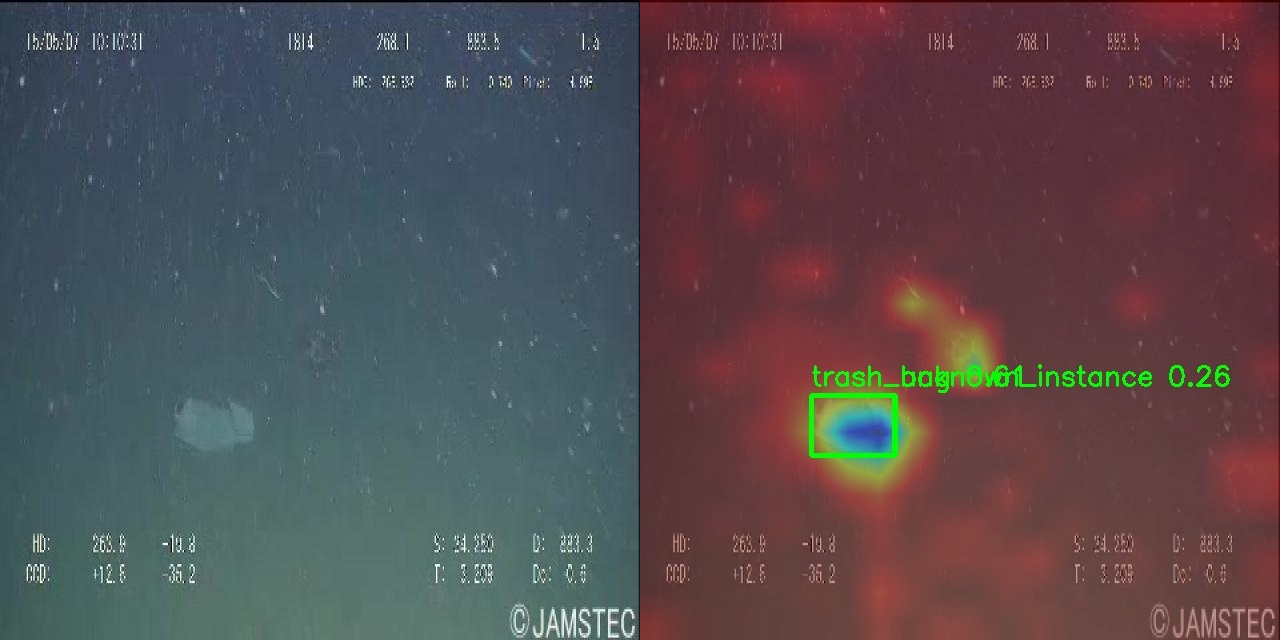

In [25]:
from IPython.display import Image, display

# Just run this cell to display the side-by-side image
display(Image(filename="/kaggle/working/gradcam_single_image/side_by_side_original_and_heatmap.jpg"))